In [2]:
%%writefile face_mask_cnn.py
import os
import sys
import numpy as np
import cv2
from pathlib import Path
from glob import glob
from tqdm import tqdm
import logging
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from skimage.feature import hog
import joblib
import json

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

IMG_SIZE = 224
LABELS = {"WithMask": 0, "WithoutMask": 1}

class SimpleFaceDetector:
    def __init__(self):
        self.face_cascade = None
        self._initialize()
    
    def _initialize(self):
        try:
            cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
            if os.path.exists(cascade_path):
                self.face_cascade = cv2.CascadeClassifier(cascade_path)
            else:
                logger.warning("Haar cascade not found, using full images")
        except:
            pass
    
    def detect_and_crop(self, img_bgr, min_size=20):
        if img_bgr is None:
            return None
        
        try:
            if self.face_cascade is not None:
                gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                faces = self.face_cascade.detectMultiScale(gray, 1.1, 4)
                
                if len(faces) > 0:
                    faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
                    x, y, w, h = faces[0]
                    
                    if w >= min_size and h >= min_size:
                        face = img_bgr[y:y+h, x:x+w]
                        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
                        face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
                        return face
            
            rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            return cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
            
        except Exception as e:
            logger.error(f"Error in face detection: {e}")
            return None

class FaceMaskDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment
        
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip() if augment else transforms.Lambda(lambda x: x),
            transforms.RandomRotation(10) if augment else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])
        image = self.transform(image)
        return image, label

class SimpleCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        ds = IMG_SIZE // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * ds * ds, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def extract_hog_features(images):
    features = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hog_feat = hog(gray, orientations=9, pixels_per_cell=(16, 16), 
                      cells_per_block=(2, 2), feature_vector=True)
        features.append(hog_feat)
    return np.array(features)

def train_svm_knn(X_train, y_train, X_val, y_val):
    print("\n ОБУЧЕНИЕ SVM И KNN МОДЕЛЕЙ")
    
    X_train_hog = extract_hog_features(X_train)
    X_val_hog = extract_hog_features(X_val)
    
    svm_model = SVC(kernel='linear', probability=True)
    svm_model.fit(X_train_hog, y_train)
    svm_acc = svm_model.score(X_val_hog, y_val)
    joblib.dump(svm_model, "model_svm_hog.pkl")
    print(f"SVM обучена | Точность: {svm_acc:.4f}")
    
    knn_model = KNeighborsClassifier(n_neighbors=3)
    knn_model.fit(X_train_hog, y_train)
    knn_acc = knn_model.score(X_val_hog, y_val)
    joblib.dump(knn_model, "model_knn_orb.pkl")
    print(f"KNN обучена | Точность: {knn_acc:.4f}")
    
    return svm_acc, knn_acc

def train_cnn_model(train_folder="Face_Mask_Dataset/Train", 
                    epochs=10, 
                    batch_size=16, 
                    model_path="model_cnn.pth"):
    
    print("ОБУЧЕНИЕ CNN, SVM И KNN МОДЕЛЕЙ")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Используется устройство: {device}")
    
    detector = SimpleFaceDetector()
    X_train_full, y_train_full = [], []
    
    for class_name, label in LABELS.items():
        class_dir = os.path.join(train_folder, class_name)
        if not os.path.exists(class_dir):
            print(f"Папка {class_dir} не найдена")
            continue
        
        files = []
        for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
            files.extend(glob(os.path.join(class_dir, f"*{ext}")))
        
        print(f"{class_name}: {len(files)} файлов")
        
        for fpath in tqdm(files[:200], desc=f"Загрузка {class_name}"):
            img = cv2.imread(fpath)
            if img is not None:
                face = detector.detect_and_crop(img)
                if face is not None:
                    X_train_full.append(face)
                    y_train_full.append(label)
    
    X_train_full = np.array(X_train_full)
    y_train_full = np.array(y_train_full)
    
    if len(X_train_full) == 0:
        print("Нет данных для обучения")
        return None
    
    print(f"\nЗагружено {len(X_train_full)} изображений")
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )
    
    print(f"Train: {len(X_train)} изображений")
    print(f"Validation: {len(X_val)} изображений")
    
    svm_acc, knn_acc = train_svm_knn(X_train, y_train, X_val, y_val)
    
    train_dataset = FaceMaskDataset(X_train, y_train, augment=True)
    val_dataset = FaceMaskDataset(X_val, y_val, augment=False)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    print("ОБУЧЕНИЕ CNN")
    
    best_val_acc = 0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * train_correct / train_total
        
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_acc = 100. * val_correct / val_total
        
        print(f"Epoch {epoch+1}: Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_path)
            print(f"Сохранена лучшая CNN модель")
    
    cnn_acc = best_val_acc / 100.0
    
    print("РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ")
    print(f"CNN Точность: {cnn_acc:.4f}")
    print(f"SVM Точность: {svm_acc:.4f}")
    print(f"KNN Точность: {knn_acc:.4f}")
    
    best_model_name = "cnn"
    if svm_acc > cnn_acc and svm_acc > knn_acc:
        best_model_name = "svm"
    elif knn_acc > cnn_acc:
        best_model_name = "knn"
    
    metrics = {
        "accuracy_cnn": float(cnn_acc),
        "accuracy_svm": float(svm_acc),
        "accuracy_knn": float(knn_acc),
        "best_model_name": best_model_name
    }
    
    with open("model_metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)
    
    print(f"\nМетрики сохранены в model_metrics.json")
    print(f"Лучшая модель: {best_model_name}")
    
    return model, cnn_acc

if __name__ == "__main__":
    model, val_acc = train_cnn_model()
    
    if model is not None:
        print(f"\nВсе модели успешно обучены")

Overwriting face_mask_cnn.py


In [3]:
%run face_mask_cnn.py
import json
import os

print("ПРОВЕРКА РЕЗУЛЬТАТОВ")

if os.path.exists("model_metrics.json"):
    with open("model_metrics.json", "r") as f:
        metrics = json.load(f)

    print("\nМетрики моделей:")
    
    for key, value in metrics.items():
        if 'accuracy' in key and value is not None:
            if isinstance(value, (int, float)):
                print(f"{key}: {value:.4f}")
            else:
                print(f"{key}: {value}")
        else:
            print(f"{key}: {value}")

    print("\nФайлы моделей:")
    model_files = {
        "SVM": "model_svm_hog.pkl",
        "KNN": "model_knn_orb.pkl", 
        "CNN": "model_cnn.pth"
    }

    for name, file in model_files.items():
        if os.path.exists(file):
            size = os.path.getsize(file) / 1024
            print(f"{name}: {file} ({size:.1f} KB)")
        else:
            print(f"{name}: {file} - не найден")
else:
    print("Файл model_metrics.json не найден")

ОБУЧЕНИЕ CNN, SVM И KNN МОДЕЛЕЙ
Используется устройство: cpu
WithMask: 126 файлов


Загрузка WithMask: 100%|████████████████████████████████████████████████████████████| 126/126 [00:00<00:00, 126.10it/s]


WithoutMask: 126 файлов


Загрузка WithoutMask: 100%|█████████████████████████████████████████████████████████| 126/126 [00:00<00:00, 139.84it/s]



Загружено 252 изображений
Train: 201 изображений
Validation: 51 изображений

 ОБУЧЕНИЕ SVM И KNN МОДЕЛЕЙ
SVM обучена | Точность: 0.9608
KNN обучена | Точность: 0.9020
ОБУЧЕНИЕ CNN


...

Epoch 8: Train Loss: 0.0609, Train Acc: 96.52%, Val Acc: 94.12%


Epoch 9/10: 100%|██████████████████████████████████████████████████████████████████████| 13/13 [00:04<00:00,  2.60it/s]


Epoch 9: Train Loss: 0.1207, Train Acc: 96.52%, Val Acc: 96.08%


Epoch 10/10: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [00:04<00:00,  3.02it/s]


Epoch 10: Train Loss: 0.1023, Train Acc: 97.01%, Val Acc: 90.20%
РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ
CNN Точность: 0.9608
SVM Точность: 0.9608
KNN Точность: 0.9020

Метрики сохранены в model_metrics.json
Лучшая модель: cnn

Все модели успешно обучены
ПРОВЕРКА РЕЗУЛЬТАТОВ

Метрики моделей:
accuracy_cnn: 0.9608
accuracy_svm: 0.9608
accuracy_knn: 0.9020
best_model_name: cnn

Файлы моделей:
SVM: model_svm_hog.pkl (5517.5 KB)
KNN: model_knn_orb.pkl (9556.1 KB)
CNN: model_cnn.pth (100723.7 KB)


ТЕСТИРОВАНИЕ ВСЕХ МОДЕЛЕЙ


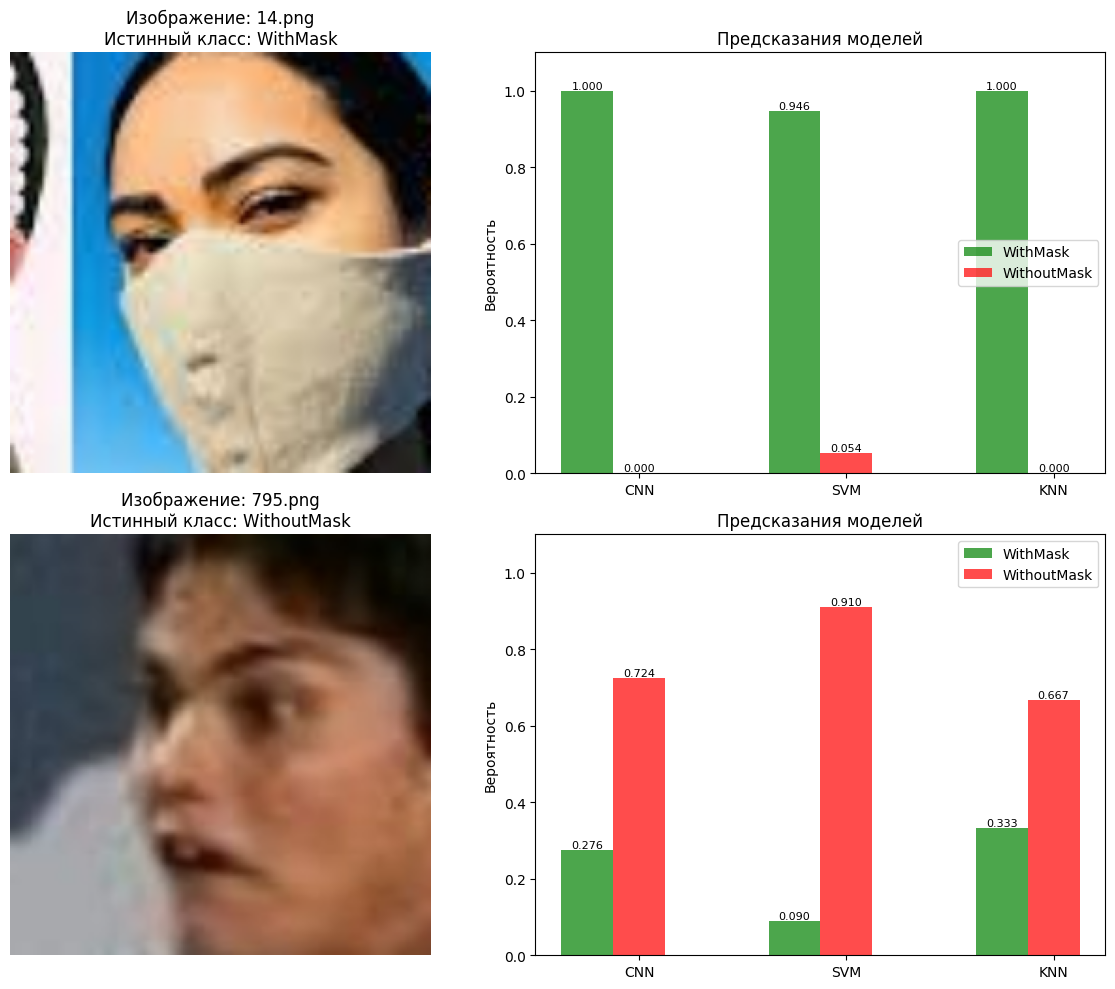


РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ:

Изображение: 14.png
Истинный класс: WithMask
CNN:  WithMask (WithMask: 1.000, WithoutMask: 0.000)
SVM:  WithMask (WithMask: 0.946, WithoutMask: 0.054)
KNN:  WithMask (WithMask: 1.000, WithoutMask: 0.000)

Изображение: 795.png
Истинный класс: WithoutMask
CNN:  WithoutMask (WithMask: 0.276, WithoutMask: 0.724)
SVM:  WithoutMask (WithMask: 0.090, WithoutMask: 0.910)
KNN:  WithoutMask (WithMask: 0.333, WithoutMask: 0.667)


In [4]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import hog
import joblib

def test_all_models_on_example():
    
    print("ТЕСТИРОВАНИЕ ВСЕХ МОДЕЛЕЙ")
    
    if not (os.path.exists("model_cnn.pth") and 
            os.path.exists("model_svm_hog.pkl") and 
            os.path.exists("model_knn_orb.pkl")):
        print("Не все модели найдены")
        return
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    class SimpleCNN(nn.Module):
        def __init__(self, n_classes=2):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            )
            ds = 224 // 8
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128 * ds * ds, 256),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(256, n_classes)
            )
        
        def forward(self, x):
            x = self.features(x)
            x = self.classifier(x)
            return x
    
    cnn_model = SimpleCNN().to(device)
    cnn_model.load_state_dict(torch.load("model_cnn.pth", map_location=device))
    cnn_model.eval()
    
    svm_model = joblib.load("model_svm_hog.pkl")
    knn_model = joblib.load("model_knn_orb.pkl")
    
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    def extract_hog_features_single(img):
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hog_feat = hog(gray, orientations=9, pixels_per_cell=(16, 16), 
                      cells_per_block=(2, 2), feature_vector=True)
        return hog_feat.reshape(1, -1)

    test_folder = "Face_Mask_Dataset/Train"
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    
    test_results = []
    
    for idx, class_name in enumerate(["WithMask", "WithoutMask"]):
        class_dir = os.path.join(test_folder, class_name)
        if os.path.exists(class_dir):
            images = [f for f in os.listdir(class_dir) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            if images:
                import random
                test_image = random.choice(images)
                img_path = os.path.join(class_dir, test_image)

                img_bgr = cv2.imread(img_path)
                if img_bgr is not None:
                    img = cv2.resize(img_bgr, (224, 224))
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    
                    axes[idx*2].imshow(img_rgb)
                    axes[idx*2].set_title(f"Изображение: {test_image}\nИстинный класс: {class_name}")
                    axes[idx*2].axis('off')
                    
                    with torch.no_grad():
                        input_tensor = transform(img_rgb).unsqueeze(0).to(device)
                        cnn_output = cnn_model(input_tensor)
                        cnn_probs = torch.softmax(cnn_output, dim=1)
                        cnn_pred_class = torch.argmax(cnn_probs, dim=1).item()
                    
                    hog_features = extract_hog_features_single(img_rgb)
                    svm_pred = svm_model.predict(hog_features)[0]
                    svm_probs = svm_model.predict_proba(hog_features)[0]
                    
                    knn_pred = knn_model.predict(hog_features)[0]
                    knn_probs = knn_model.predict_proba(hog_features)[0]
                    
                    labels = {0: "WithMask", 1: "WithoutMask"}
                    
                    model_names = ['CNN', 'SVM', 'KNN']
                    predictions = [
                        f"{labels[cnn_pred_class]} ({cnn_probs[0][cnn_pred_class]:.3f})",
                        f"{labels[svm_pred]} ({svm_probs[svm_pred]:.3f})",
                        f"{labels[knn_pred]} ({knn_probs[knn_pred]:.3f})"
                    ]
                    
                    x_pos = np.arange(len(model_names))
                    width = 0.25
                    
                    with_mask_probs = [
                        float(cnn_probs[0][0]),
                        svm_probs[0],
                        knn_probs[0]
                    ]
                    
                    without_mask_probs = [
                        float(cnn_probs[0][1]),
                        svm_probs[1],
                        knn_probs[1]
                    ]
                    
                    ax = axes[idx*2 + 1]
                    bars1 = ax.bar(x_pos - width, with_mask_probs, width, label='WithMask', color='green', alpha=0.7)
                    bars2 = ax.bar(x_pos, without_mask_probs, width, label='WithoutMask', color='red', alpha=0.7)
                    
                    ax.set_ylabel('Вероятность')
                    ax.set_title(f'Предсказания моделей')
                    ax.set_xticks(x_pos)
                    ax.set_xticklabels(model_names)
                    ax.legend()

                    for bars in [bars1, bars2]:
                        for bar in bars:
                            height = bar.get_height()
                            ax.text(bar.get_x() + bar.get_width()/2., height,
                                   f'{height:.3f}',
                                   ha='center', va='bottom', fontsize=8)
                    
                    ax.set_ylim([0, 1.1])

                    test_results.append({
                        'image': test_image,
                        'true_class': class_name,
                        'cnn_pred': labels[cnn_pred_class],
                        'cnn_probs': [float(cnn_probs[0][0]), float(cnn_probs[0][1])],
                        'svm_pred': labels[svm_pred],
                        'svm_probs': [float(svm_probs[0]), float(svm_probs[1])],
                        'knn_pred': labels[knn_pred],
                        'knn_probs': [float(knn_probs[0]), float(knn_probs[1])]
                    })
    
    plt.tight_layout()
    plt.show()
    
    print("\nРЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ:")
    
    for result in test_results:
        print(f"\nИзображение: {result['image']}")
        print(f"Истинный класс: {result['true_class']}")
        print(f"CNN:  {result['cnn_pred']} (WithMask: {result['cnn_probs'][0]:.3f}, WithoutMask: {result['cnn_probs'][1]:.3f})")
        print(f"SVM:  {result['svm_pred']} (WithMask: {result['svm_probs'][0]:.3f}, WithoutMask: {result['svm_probs'][1]:.3f})")
        print(f"KNN:  {result['knn_pred']} (WithMask: {result['knn_probs'][0]:.3f}, WithoutMask: {result['knn_probs'][1]:.3f})")
    
    return test_results

try:
    test_results = test_all_models_on_example()
except Exception as e:
    print(f"Ошибка тестирования: {e}")

In [5]:
%%writefile run_bot.py
import os
import json
import cv2
import numpy as np
import torch
import joblib
from telegram import Update, InlineKeyboardButton, InlineKeyboardMarkup
from telegram.ext import Application, CommandHandler, MessageHandler, CallbackQueryHandler, filters, ContextTypes
from PIL import Image
import io
from skimage.feature import hog
import torch.nn as nn
from torchvision import transforms

print("ПРОВЕРКА МОДЕЛЕЙ ДЛЯ ТЕЛЕГРАМ БОТА")

MODEL_FILES = {
    "cnn": "model_cnn.pth",
    "svm": "model_svm_hog.pkl", 
    "knn": "model_knn_orb.pkl",
    "metrics": "model_metrics.json"
}

for name, file in MODEL_FILES.items():
    if os.path.exists(file):
        print(f"{name.upper()}: {file} - найден")
    else:
        print(f"{name.upper()}: {file} - не найден")

if os.path.exists("model_metrics.json"):
    with open("model_metrics.json", "r") as f:
        metrics = json.load(f)
    print("МЕТРИКИ МОДЕЛЕЙ:")
    for key, value in metrics.items():
        if 'accuracy' in key:
            print(f"  {key}: {value:.4f} ({value*100:.1f}%)")
    print(f"Лучшая модель: {metrics.get('best_model_name', 'unknown')}")
else:
    print("Файл метрик не найден")
    metrics = {}

IMG_SIZE = 224
LABELS = {0: "С МАСКОЙ", 1: "БЕЗ МАСКИ"}

class SimpleCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        ds = IMG_SIZE // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * ds * ds, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def load_models():
    models = {}
    
    if os.path.exists("model_cnn.pth"):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = SimpleCNN().to(device)
        model.load_state_dict(torch.load("model_cnn.pth", map_location=device))
        model.eval()
        models["cnn"] = model
        print("CNN модель загружена")

    if os.path.exists("model_svm_hog.pkl"):
        models["svm"] = joblib.load("model_svm_hog.pkl")
        print("SVM модель загружена")

    if os.path.exists("model_knn_orb.pkl"):
        models["knn"] = joblib.load("model_knn_orb.pkl")
        print("KNN модель загружена")
    
    return models

MODELS = load_models()
print(f"Всего загружено моделей: {len(MODELS)}")

def process_image(image_bytes):
    image = Image.open(io.BytesIO(image_bytes))
    image = image.convert('RGB')
    img_array = np.array(image)
    img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    img_resized = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    return img_rgb

def get_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hog_feat = hog(gray, orientations=9, pixels_per_cell=(16, 16),
                  cells_per_block=(2, 2), feature_vector=True)
    return hog_feat.reshape(1, -1)

async def start(update: Update, context: ContextTypes.DEFAULT_TYPE):
    keyboard = [
        [InlineKeyboardButton("📊 Метрики моделей", callback_data="metrics")],
        [InlineKeyboardButton("🤖 CNN модель", callback_data="cnn")],
        [InlineKeyboardButton("📊 SVM модель", callback_data="svm")],
        [InlineKeyboardButton("📈 KNN модель", callback_data="knn")],
        [InlineKeyboardButton("🏆 Лучшая модель", callback_data="best")],
        [InlineKeyboardButton("📸 Все модели", callback_data="all")]
    ]
    reply_markup = InlineKeyboardMarkup(keyboard)
    
    await update.message.reply_text(
        "👋 Я бот для определения масок!\n"
        "📸 Отправьте мне фото лица, и я скажу есть ли на нём маска.\n\n"
        "🤖 Используемые модели:\n"
        "• CNN (нейросеть)\n"
        "• SVM (метод опорных векторов)\n"
        "• KNN (метод ближайших соседей)\n\n"
        "Выберите действие:",
        reply_markup=reply_markup
    )

async def info(update: Update, context: ContextTypes.DEFAULT_TYPE):
    if metrics:
        msg = "📊 МЕТРИКИ МОДЕЛЕЙ:\n\n"
        for key, value in metrics.items():
            if 'accuracy' in key:
                model_name = key.replace('accuracy_', '').upper()
                msg += f"{model_name}: {value:.4f} ({value*100:.1f}%)\n"
        msg += f"\n🏆 Лучшая модель: {metrics.get('best_model_name', 'unknown').upper()}"
    else:
        msg = "❌ Метрики не найдены"
    
    await update.message.reply_text(msg)

async def handle_photo(update: Update, context: ContextTypes.DEFAULT_TYPE):
    photo_file = await update.message.photo[-1].get_file()
    photo_bytes = await photo_file.download_as_bytearray()
    
    # Сохраняем фото в контексте
    context.user_data["last_photo"] = photo_bytes
    
    keyboard = [
        [InlineKeyboardButton("🤖 CNN", callback_data="predict_cnn"),
         InlineKeyboardButton("📊 SVM", callback_data="predict_svm")],
        [InlineKeyboardButton("📈 KNN", callback_data="predict_knn"),
         InlineKeyboardButton("🏆 Лучшая", callback_data="predict_best")],
        [InlineKeyboardButton("📸 Все модели", callback_data="predict_all")]
    ]
    reply_markup = InlineKeyboardMarkup(keyboard)
    
    await update.message.reply_text(
        "🖼 Фото получено! Выберите модель для анализа:",
        reply_markup=reply_markup
    )

async def button_handler(update: Update, context: ContextTypes.DEFAULT_TYPE):
    query = update.callback_query
    await query.answer()
    
    data = query.data
    
    if data == "metrics":
        if metrics:
            msg = "📊 МЕТРИКИ МОДЕЛЕЙ:\n\n"
            for key, value in metrics.items():
                if 'accuracy' in key:
                    model_name = key.replace('accuracy_', '').upper()
                    msg += f"{model_name}: {value:.4f} ({value*100:.1f}%)\n"
            msg += f"\n🏆 Лучшая модель: {metrics.get('best_model_name', 'unknown').upper()}"
            await query.edit_message_text(msg)
    
    elif data in ["cnn", "svm", "knn", "best", "all"]:
        model_name = data.upper()
        if data == "best":
            model_name = metrics.get("best_model_name", "unknown").upper()
        
        await query.edit_message_text(
            f"📸 Отправьте фото для анализа моделью {model_name}"
        )
    
    elif data.startswith("predict_"):
        model_type = data.replace("predict_", "")
        
        if "last_photo" not in context.user_data:
            await query.edit_message_text("❌ Фото не найдено")
            return
        
        photo_bytes = context.user_data["last_photo"]
        img = process_image(photo_bytes)
        
        if model_type == "all":
            results = []
            
            if "cnn" in MODELS:
                transform = transforms.Compose([
                    transforms.ToPILImage(),
                    transforms.ToTensor(),
                    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                ])
                device = next(MODELS["cnn"].parameters()).device
                with torch.no_grad():
                    input_tensor = transform(img).unsqueeze(0).to(device)
                    output = MODELS["cnn"](input_tensor)
                    probs = torch.softmax(output, dim=1)
                    pred = torch.argmax(probs, dim=1).item()
                results.append(f"🤖 CNN: {LABELS[pred]} (маска: {probs[0][0]:.3f}, без: {probs[0][1]:.3f})")
            
            if "svm" in MODELS:
                features = get_hog_features(img)
                pred = MODELS["svm"].predict(features)[0]
                probs = MODELS["svm"].predict_proba(features)[0]
                results.append(f"📊 SVM: {LABELS[pred]} (маска: {probs[0]:.3f}, без: {probs[1]:.3f})")
            
            if "knn" in MODELS:
                features = get_hog_features(img)
                pred = MODELS["knn"].predict(features)[0]
                probs = MODELS["knn"].predict_proba(features)[0]
                results.append(f"📈 KNN: {LABELS[pred]} (маска: {probs[0]:.3f}, без: {probs[1]:.3f})")
            
            if results:
                msg = "📊 РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ:\n\n" + "\n".join(results)
                best_model = metrics.get("best_model_name", "unknown").upper()
                msg += f"\n\n🏆 Лучшая модель: {best_model}"
            else:
                msg = "❌ Модели не загружены"
            
            await query.edit_message_text(msg)
        
        else:
            if model_type not in MODELS:
                await query.edit_message_text(f"❌ Модель {model_type.upper()} не загружена")
                return
            
            if model_type == "cnn":
                transform = transforms.Compose([
                    transforms.ToPILImage(),
                    transforms.ToTensor(),
                    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                ])
                device = next(MODELS["cnn"].parameters()).device
                with torch.no_grad():
                    input_tensor = transform(img).unsqueeze(0).to(device)
                    output = MODELS["cnn"](input_tensor)
                    probs = torch.softmax(output, dim=1)
                    pred = torch.argmax(probs, dim=1).item()
                
                msg = f"🤖 CNN МОДЕЛЬ:\n\n"
                msg += f"Результат: {LABELS[pred]}\n"
                msg += f"Вероятность маски: {probs[0][0]:.3f}\n"
                msg += f"Вероятность без маски: {probs[0][1]:.3f}\n"
                msg += f"\nТочность модели: {metrics.get('accuracy_cnn', 'N/A'):.4f}"
            
            elif model_type in ["svm", "knn"]:
                features = get_hog_features(img)
                model = MODELS[model_type]
                pred = model.predict(features)[0]
                probs = model.predict_proba(features)[0]
                
                model_name = model_type.upper()
                msg = f"{'📊 SVM' if model_type == 'svm' else '📈 KNN'} МОДЕЛЬ:\n\n"
                msg += f"Результат: {LABELS[pred]}\n"
                msg += f"Вероятность маски: {probs[0]:.3f}\n"
                msg += f"Вероятность без маски: {probs[1]:.3f}\n"
                msg += f"\nТочность модели: {metrics.get(f'accuracy_{model_type}', 'N/A'):.4f}"
            
            elif model_type == "best":
                best_model = metrics.get("best_model_name", "unknown")
                if best_model in MODELS:
                    if best_model == "cnn":
                        transform = transforms.Compose([
                            transforms.ToPILImage(),
                            transforms.ToTensor(),
                            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                        ])
                        device = next(MODELS["cnn"].parameters()).device
                        with torch.no_grad():
                            input_tensor = transform(img).unsqueeze(0).to(device)
                            output = MODELS["cnn"](input_tensor)
                            probs = torch.softmax(output, dim=1)
                            pred = torch.argmax(probs, dim=1).item()
                    else:
                        features = get_hog_features(img)
                        model = MODELS[best_model]
                        pred = model.predict(features)[0]
                        probs = model.predict_proba(features)[0]
                    
                    msg = f"🏆 ЛУЧШАЯ МОДЕЛЬ ({best_model.upper()}):\n\n"
                    msg += f"Результат: {LABELS[pred]}\n"
                    msg += f"Вероятность маски: {probs[0] if isinstance(probs, np.ndarray) else float(probs[0]):.3f}\n"
                    msg += f"Вероятность без маски: {probs[1] if isinstance(probs, np.ndarray) else float(probs[1]):.3f}\n"
                    msg += f"\nТочность модели: {metrics.get(f'accuracy_{best_model}', 'N/A'):.4f}"
                else:
                    msg = f"❌ Лучшая модель {best_model.upper()} не загружена"
            
            await query.edit_message_text(msg)
            
def main():
    TOKEN = "8531592850:AAEJmozYY2YgeKObWTT6HcinZXXct7YaV8s"
    app = Application.builder().token(TOKEN).build()
    
    app.add_handler(CommandHandler("start", start))
    app.add_handler(CommandHandler("info", info))
    app.add_handler(MessageHandler(filters.PHOTO, handle_photo))
    app.add_handler(CallbackQueryHandler(button_handler))
    
    print("🤖 БОТ ЗАПУЩЕН")
    print("1. Откройте Telegram")
    print("2. Найдите своего бота")
    print("3. Отправьте команду /start")
    
    app.run_polling()

if __name__ == "__main__":
    main()

Overwriting run_bot.py


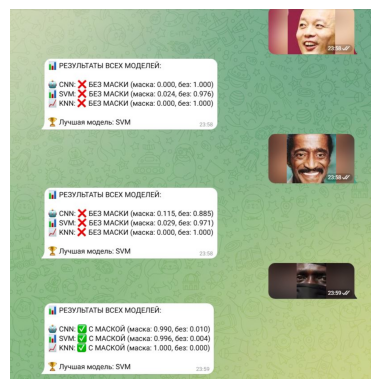

In [12]:
image = cv2.imread(r"C:\Users\User\Documents\Project\Project\12221.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  
plt.imshow(image_rgb)
plt.axis('off')  
plt.show()


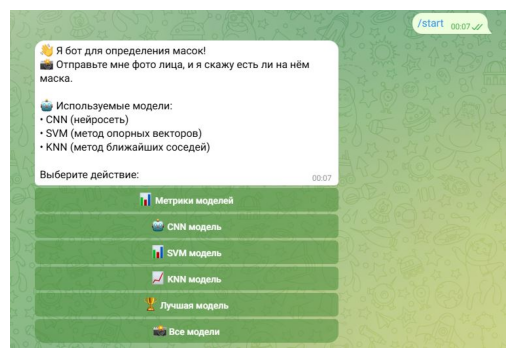

In [13]:
image = cv2.imread(r"C:\Users\User\Documents\Project\Project\67.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  
plt.imshow(image_rgb)
plt.axis('off')  
plt.show()